 RESULTADOS DEL MODELO EN EL CONJUNTO DE PRUEBA 
[RF] Out-of-bag error accuracy of examples  xi: 0.893
Random Forest -> Recall: 92.97% | ROC-AUC: 0.9535
XGBoost       -> Recall: 93.51% | ROC-AUC: 0.9483


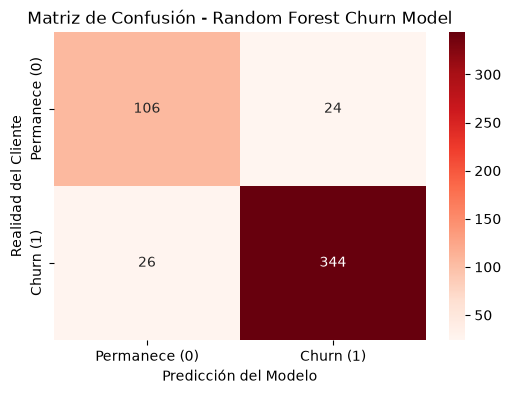

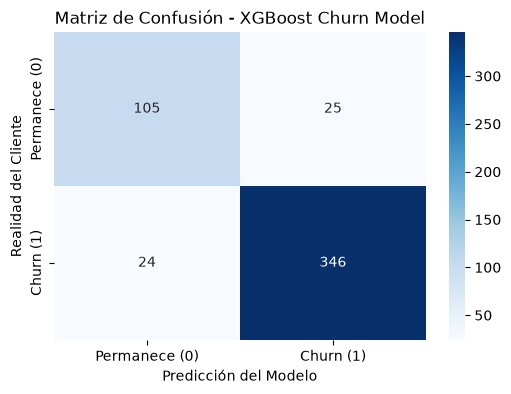

In [ ]:
from sklearn.model_selection    import train_test_split
from sklearn.ensemble           import RandomForestClassifier
from xgboost                    import XGBClassifier
from sklearn.metrics            import classification_report, roc_auc_score, confusion_matrix, recall_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Churn Predictor and LTV\data\processed\churn_feature_data.csv"
df = pd.read_csv(path)

X = df.drop(columns=["CustomerID", "Churn", "FutureLTV_12M"])
y = df["Churn"]

# Codificación One-Hot para variables categóricas (ContractType, PaymentMethod) y (False) mantener la explicabilidad
X = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entrenamiento de Modelos
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True, n_jobs=-1).fit(X_train, y_train)

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42, eval_metric="logloss", n_jobs=-1).fit(X_train, y_train)

# Predicciones
y_hat_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

y_hat_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]


# Resultados y Comparación de Métricas
print("="*50)
print(" RESULTADOS DEL MODELO EN EL CONJUNTO DE PRUEBA ")
print("="*50)
print(f"[RF] Out-of-bag error accuracy of examples  xi: {rf_model.oob_score_}")
print(f"Random Forest -> Recall: {recall_score(y_test, y_hat_rf):.2%} | ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"XGBoost       -> Recall: {recall_score(y_test, y_hat_xgb):.2%} | ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print("="*50)


# Matriz de Confusión para Random Forest
cm = confusion_matrix(y_test, y_hat_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Permanece (0)', 'Churn (1)'], yticklabels=['Permanece (0)', 'Churn (1)'])
plt.title('Matriz de Confusión - Random Forest Churn Model')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Cliente')
plt.show()


# Matriz de Confusión para XGBoost
cm = confusion_matrix(y_test, y_hat_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Permanece (0)', 'Churn (1)'], yticklabels=['Permanece (0)', 'Churn (1)'])
plt.title('Matriz de Confusión - XGBoost Churn Model')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Cliente')
plt.show()

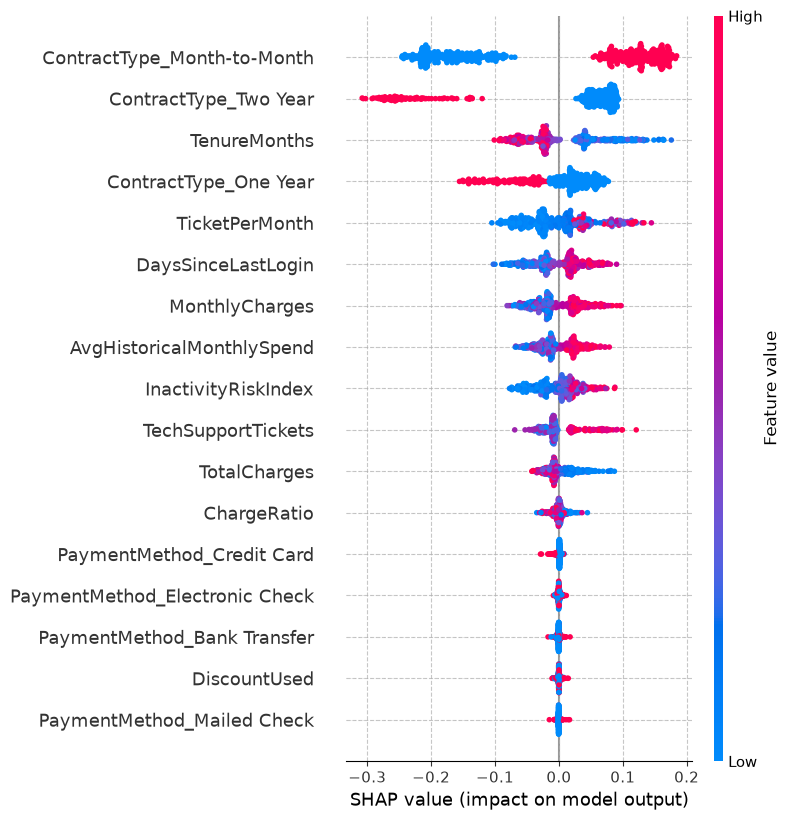

In [37]:
""" SHAP (SHapley Additive exPlanations) con RF """
import shap

# Crear el explicador de SHAP basado en árboles
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf(X_test)

# Summary Plot: Importancia global y dirección del impacto de las variables
plt.figure(figsize=(10,6))
# El arreglo de SHAP se vuelve 3D:la variable shap_values guarda un objeto tridimensional con la forma (N_muestras, N_features, N_clases)
shap.summary_plot(shap_values_rf[:, :, 1], X_test, show=False)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

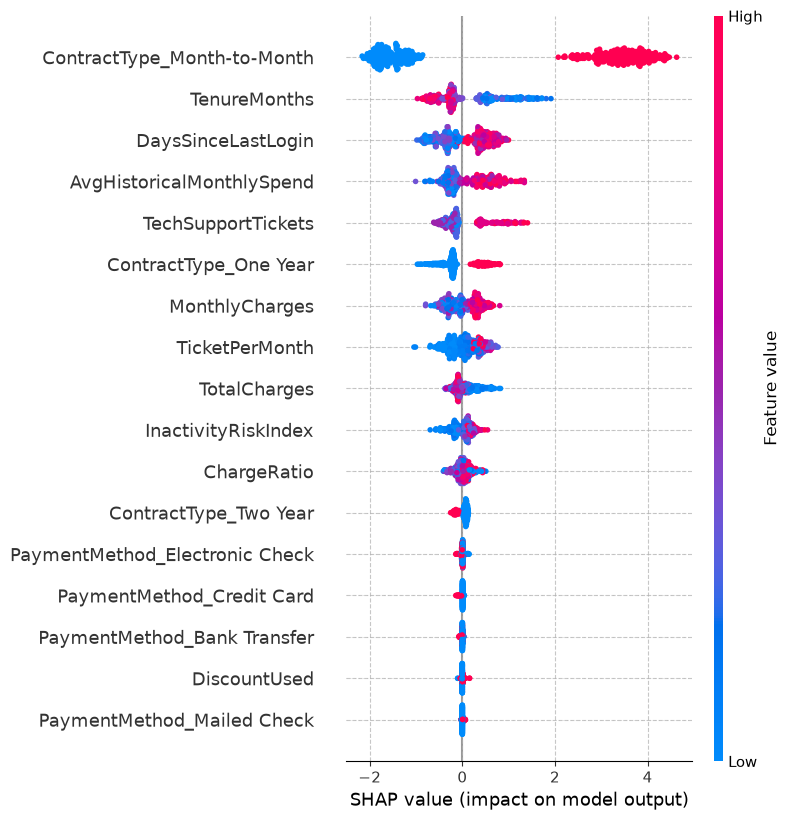

In [36]:
""" SHAP (SHapley Additive exPlanations) con XGB """
import shap

# Crear el explicador de SHAP basado en árboles
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb(X_test)

# 1. Summary Plot: Importancia global y dirección del impacto de las variables
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_test, show=False)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [40]:
df["FutureLTV_12M"].describe(include="all")

count    2500.000000
mean      268.676552
std       353.890021
min        11.300000
25%        59.165000
50%       107.115000
75%       273.287500
max      1621.660000
Name: FutureLTV_12M, dtype: float64

<Axes: xlabel='Churn', ylabel='FutureLTV_12M'>

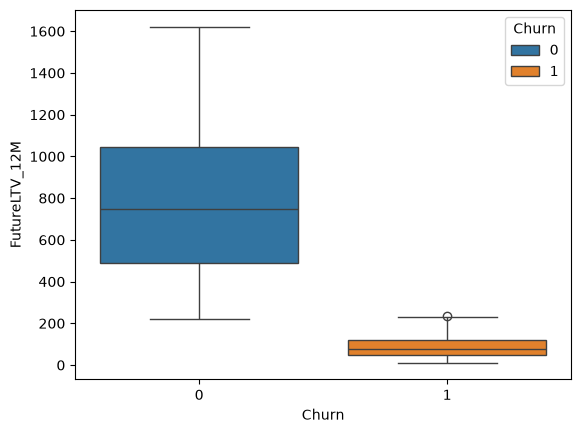

In [41]:
sns.boxplot(data=df, x="Churn", y="FutureLTV_12M", hue="Churn")